In [644]:
###############
## FUNCTIONS ##
###############

def normalise(x):
    """
    """
    return (x - x.min())/(x.max() - x.min())

def bin_y_along_x(arr_x, x_index, arr_y, y_index):
    """
    """
    x_unique = np.unique(arr_x[:,x_index])
    y_binned = []
    for x_unique_ in x_unique:
        s = np.argwhere(arr_x[:,x_index] == x_unique_)
        y_binned += [np.mean(arr_y[s,y_index])]
    y_binned = np.array(y_binned)
    return x_unique, y_binned  

def collapse_columns_2Darray_to_string(arr, sep=""):
    """
    """
    arr_str = []
    for arr_ in arr:
        arr_ = [arr__ for arr__ in arr_.astype(str)]
        arr_ = sep.join(arr_)
        arr_str += [arr_]
    return np.array(arr_str)

def load_data(pwd, fold_number):
    """
    Loads hyperparameter data for a specific fold from the given directory.

    Parameters:
    pwd (str): The path to the directory containing the data.
    fold_number (int): The fold number to load data for.

    Returns:
    tuple: Arrays of hyperparameters, train AUCs, validation AUCs, and test AUCs.
    """
    pti = os.path.join(pwd, f"hypertrain_fold_{fold_number}/")
    ht = pickle.load(open(os.path.join(pti, "obj_hypertrain_list.pkl"), "rb"))
    
    hp, train, val, test = [], [], [], []
    for ht_ in ht:
        hp.append(ht_[:5])
        train.append(ht_[5])
        val.append(ht_[6])
        test.append(ht_[7])
        
    return np.array(hp), np.array(train), np.array(val), np.array(test)

def load_fold_data(pwd, folds):
    """
    """
    hp, train, val, test = [], [], [], []
    for fold in folds:
        fold_hp, fold_train, fold_val, fold_test = load_data(pwd, fold)
        hp.append(fold_hp)
        train.append(fold_train)
        val.append(fold_val)
        test.append(fold_test)
    return np.concatenate(hp), np.concatenate(train), np.concatenate(val), np.concatenate(test)

def compute_unique_hyperparameter_sets(hp_data, column_indices, separator="_"):
    """Compute unique combinations of hyperparameters and their indices."""
    hp_keys = collapse_columns_2Darray_to_string(hp_data[:, column_indices], sep=separator)
    hp_keys_unique = np.unique(hp_keys)
    hp_set_index = np.arange(len(hp_keys_unique)) + 1
    return hp_keys, hp_keys_unique, hp_set_index

def assemble_data_by_hyperparameter_sets(hp_keys, hp_keys_unique, target_array):
    """Assemble validation AUCs grouped by unique hyperparameter sets."""
    x_data = []
    y_data = []
    for hp_keys_unique_ in hp_keys_unique:
        s = np.argwhere(hp_keys == hp_keys_unique_)
        x_data.append(hp_keys_unique_)
        y_data.append(target_array.mean(1)[s].flatten())
    return x_data, y_data

def remove_nan_from_data(y_data):
    """Remove NaN values from the AUC data."""
    return [arr[~np.isnan(arr)] for arr in y_data]

def plot_boxplot(y_data):
    """Plot a boxplot of the validation AUCs for each hyperparameter set."""
    plt.boxplot(y_data)
    plt.xlabel("Hyperparameter Set")
    plt.ylabel("Validation AUC")
    plt.title("Comparison of validation AUC of hyperparameter sets")
    plt.tight_layout()
    plt.show()
    plt.close()

def compute_and_plot_mean_auc(y_data, hp_set_index, plot=False):
    """Compute and plot the mean AUC for each hyperparameter set."""
    auc_list = [np.mean(y_) for y_ in y_data]
    if plot == True:
        plt.scatter(hp_set_index, auc_list)
        plt.plot([0, len(hp_set_index)], [0, 0], linestyle="--", color="black")
        for i in range(len(auc_list)):
            plt.plot([hp_set_index[i], hp_set_index[i]], [0, auc_list[i]])
    
        plt.xlim(1-0.5, len(hp_set_index)+0.5)
        plt.xlabel("Hyperparameter Set")
        plt.ylabel("Mean Validation AUC")
        plt.title("Comparison of validation AUC of hyperparameter sets")
        plt.tight_layout()
        plt.show()
        plt.close()
    return auc_list

def compute_and_plot_t_statistic(y_data, hp_set_index, plot=False):
    """Compute and plot the t-statistic for each hyperparameter set."""
    mean_y_data = np.mean(np.concatenate(y_data))
    std_y_data = np.std(np.concatenate(y_data))
    t_list = [(np.mean(y_) - mean_y_data) / std_y_data for y_ in y_data]

    if plot == True:
        plt.scatter(hp_set_index, t_list)
        plt.plot([0, len(hp_set_index)], [0, 0], linestyle="--", color="black")
        for i in range(len(t_list)):
            plt.plot([hp_set_index[i], hp_set_index[i]], [0, t_list[i]])
    
        plt.xlim(1-0.5, len(hp_set_index)+0.5)
        plt.xlabel("Hyperparameter Set")
        plt.ylabel("t-statistic of Validation AUC")
        plt.title("Comparison of validation t-statistics of hyperparameter sets")
        plt.tight_layout()
        plt.show()
        plt.close()
        
    return t_list

def identify_best_hyperparameter_set(t_list, hp_keys_unique):
    """Identify the best hyperparameter set based on the t-statistic."""
    hp_star_index = np.argmax(t_list)
    hp_star = hp_keys_unique[hp_star_index]
    return hp_star_index + 1, hp_star

def load_and_process_folds(pwd, folds, column_indices, plot=False):
    """Load data from multiple folds and process hyperparameter sets and AUCs."""
    hp, train, val, test = load_fold_data(pwd, folds)

    # Compute unique hyperparameter sets
    hp_keys, hp_keys_unique, hp_set_index = compute_unique_hyperparameter_sets(hp, column_indices)

    # Assemble data by hyperparameter sets
    x_data, y_data = assemble_data_by_hyperparameter_sets(hp_keys, hp_keys_unique, val)

    # Remove NaNs from data
    y_data = remove_nan_from_data(y_data)

    # Plot boxplot
    if plot == True:
        plot_boxplot(y_data)

    # Compute and plot mean AUC
    auc_list = compute_and_plot_mean_auc(y_data, hp_set_index)

    # Compute and plot t-statistic
    t_list = compute_and_plot_t_statistic(y_data, hp_set_index)

    # Identify and print the best hyperparameter set
    hp_star_index, hp_star = identify_best_hyperparameter_set(t_list, hp_keys_unique)
    print(f"The best hyperparameter set is: {hp_star_index}")
    print(f"HP star is: {hp_star}")

    # Save the best hyperparameter set
    return hp_star

def load_and_process_folds_separately(pwd, folds, column_indices, plot=False):
    """Load and process each fold separately, generating plots and identifying the best hyperparameter set for each."""
    hp_star_all = []
    hp_all_folds = []
    train_all_folds = []
    val_all_folds = []
    test_all_folds = []

    for fold in folds:
        print(f"Processing fold {fold}...")

        # Load data for the specific fold
        hp, train, val, test = load_data(pwd, fold)

        # Store the loaded data
        hp_all_folds.append(hp)
        train_all_folds.append(train)
        val_all_folds.append(val)
        test_all_folds.append(test)

        # Compute unique hyperparameter sets
        hp_keys, hp_keys_unique, hp_set_index = compute_unique_hyperparameter_sets(hp, column_indices)

        # Assemble data by hyperparameter sets
        x_data, y_data = assemble_data_by_hyperparameter_sets(hp_keys, hp_keys_unique, val)

        # Remove NaNs from data
        y_data = remove_nan_from_data(y_data)

        # Plot boxplot
        if plot == True:
            plot_boxplot(y_data)

        # Compute and plot mean AUC
        auc_list = compute_and_plot_mean_auc(y_data, hp_set_index)

        # Compute and plot t-statistic
        t_list = compute_and_plot_t_statistic(y_data, hp_set_index)

        # Identify and print the best hyperparameter set
        hp_star_index, hp_star = identify_best_hyperparameter_set(t_list, hp_keys_unique)
        print(f"Best hyperparameter set for fold {fold} is: {hp_star_index}")
        print(f"HP star is: {hp_star}")

        # Save the best hyperparameter set for this fold
        hp_star_all.append(hp_star)

    return hp_star_all, hp_all_folds, train_all_folds, val_all_folds, test_all_folds

def plot_auc_violin(all_folds_data, labels, title):
    """Plot a violin plot comparing AUC data across different folds for each label."""
    plt.figure(figsize=(12, 6))
    fontsize = 12

    colors = ['grey', 'salmon', 'skyblue', 'limegreen', 'orange']  # Example colors for each fold
    data_offsets = np.linspace(-0.2, 0.2, len(all_folds_data))  # Spread data points to avoid overlap

    for i, (fold_data, color, offset) in enumerate(zip(all_folds_data, colors, data_offsets)):
        x = [1 + offset + j for j in range(len(fold_data))]
        parts = plt.violinplot(fold_data, positions=x, showmeans=False, showmedians=False, showextrema=False)
        for pc in parts['bodies']:
            pc.set_facecolor(color)
            pc.set_alpha(0.5)
        q05, quartile1, medians, quartile3, q95 = np.percentile(fold_data, [5, 25, 50, 75, 95], axis=1)
        inds = np.arange(1, len(medians) + 1) + offset
        means = np.mean(fold_data, axis=1)
        plt.scatter(inds, means, marker='o', color='red', s=30, zorder=3)
        plt.scatter(inds, medians, marker='o', color='white', s=30, zorder=3)
        plt.vlines(inds, quartile1, quartile3, color='k', linestyle='-', lw=5)
        plt.vlines(inds, q05, q95, color='k', linestyle='-', lw=1)

    # Add line at 0.5
    plt.axhline(y=0.5, linestyle='--', color='gray')

    # Legend
    custom_lines = [Line2D([0], [0], color=color, lw=2) for color in colors[:len(all_folds_data)]]
    plt.legend(custom_lines, [f'Fold {i+1}' for i in range(len(all_folds_data))], loc='lower right', frameon=False, fontsize=fontsize)

    # Graphical parameters
    sns.set(font_scale=1.2)
    plt.xticks(np.arange(1, len(labels) + 1), labels=labels, rotation='vertical', size=fontsize)
    plt.xlabel("")
    plt.ylabel("Accuracy of detection (AUROC)", size=fontsize)
    plt.ylim(0.25, 1)
    plt.xlim(0, len(labels) + 1)
    plt.title(title)
    plt.tight_layout()
    plt.show()
    plt.close()

def prepare_fold_data(hp_star, hp_keys, aucs):
    """Prepare the data for the best model across multiple folds."""
    indices = np.argwhere(hp_star == hp_keys).flatten()
    auc_star = aucs[indices]
    if len(auc_star.shape) == 1:
        auc_star = auc_star.reshape(-1, 1)
    return [auc_star[:, i] for i in range(auc_star.shape[1])]

def plot_auc_bars(all_folds_data, labels, title):
    """Plot bars comparing AUC data across different folds for each label."""
    plt.figure(figsize=(12, 6))
    fontsize = 12

    colors = ['grey', 'salmon', 'skyblue', 'limegreen', 'orange']  # Colors for each fold
    data_offsets = np.linspace(-0.3, 0.3, len(all_folds_data))  # Spread data points to avoid overlap

    for i, (fold_data, color, offset) in enumerate(zip(all_folds_data, colors, data_offsets)):
        x = np.arange(1, len(fold_data) + 1) + offset  # Adjust the position to avoid overlap
        q05, quartile1, medians, quartile3, q95 = np.percentile(fold_data, [5, 25, 50, 75, 95], axis=1)
        means = np.mean(fold_data, axis=1)

        # Plot bars (vlines)
        plt.scatter(x, means, marker='o', color='red', s=30, zorder=3)
        plt.scatter(x, medians, marker='o', color='white', s=30, zorder=3)
        plt.vlines(x, quartile1, quartile3, color=color, linestyle='-', lw=5)
        plt.vlines(x, q05, q95, color=color, linestyle='-', lw=1)

    # Add line at 0.5
    plt.axhline(y=0.5, linestyle='--', color='gray')

    # Legend
    custom_lines = [Line2D([0], [0], color=color, lw=2) for color in colors[:len(all_folds_data)]]
    plt.legend(custom_lines, [f'Fold {i+1}' for i in range(len(all_folds_data))], loc='upper right', frameon=False, fontsize=fontsize)

    # Graphical parameters
    sns.set(font_scale=1.2)
    plt.xticks(np.arange(1, len(labels) + 1), labels=labels, rotation='vertical', size=fontsize)
    plt.xlabel("")
    plt.ylabel("Accuracy of detection (AUROC)", size=fontsize)
    plt.ylim(0.25, 1)
    plt.xlim(0, len(labels) + 1)
    plt.title(title)
    plt.tight_layout()
    plt.show()
    plt.close()
    
#
###

In [629]:
##############
## INITIATE ##
##############

## Imports
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

#
###

In [633]:

# MAIN SCRIPT

# Define paths and folds
pwd = "/Users/willembonnaffe/Documents/Academia/Projects/PAW-MIL-2D-PPCG/outputs/PPCG_MQ_SmallMediumNozeroNew_256_MultiTask_Augmented_all/aggregator-hypertrain/singletask-clinical_gleason_index_1/"
folds = [1, 2, 3, 4, 5]
column_indices = [2, 3, 4]

# Load, process, and retrieve best hyperparameter set and fold data
hp_star_all_folds, hp_all_folds, train_all_folds, val_all_folds, test_all_folds = load_and_process_folds_separately(pwd, folds, column_indices)

Processing fold 1...
Best hyperparameter set for fold 1 is: 1
HP star is: 32.0_4.0_0.001
Processing fold 2...
Best hyperparameter set for fold 2 is: 1
HP star is: 32.0_4.0_0.001
Processing fold 3...
Best hyperparameter set for fold 3 is: 1
HP star is: 32.0_4.0_0.001
Processing fold 4...
Best hyperparameter set for fold 4 is: 1
HP star is: 32.0_4.0_0.001
Processing fold 5...
Best hyperparameter set for fold 5 is: 1
HP star is: 32.0_4.0_0.001


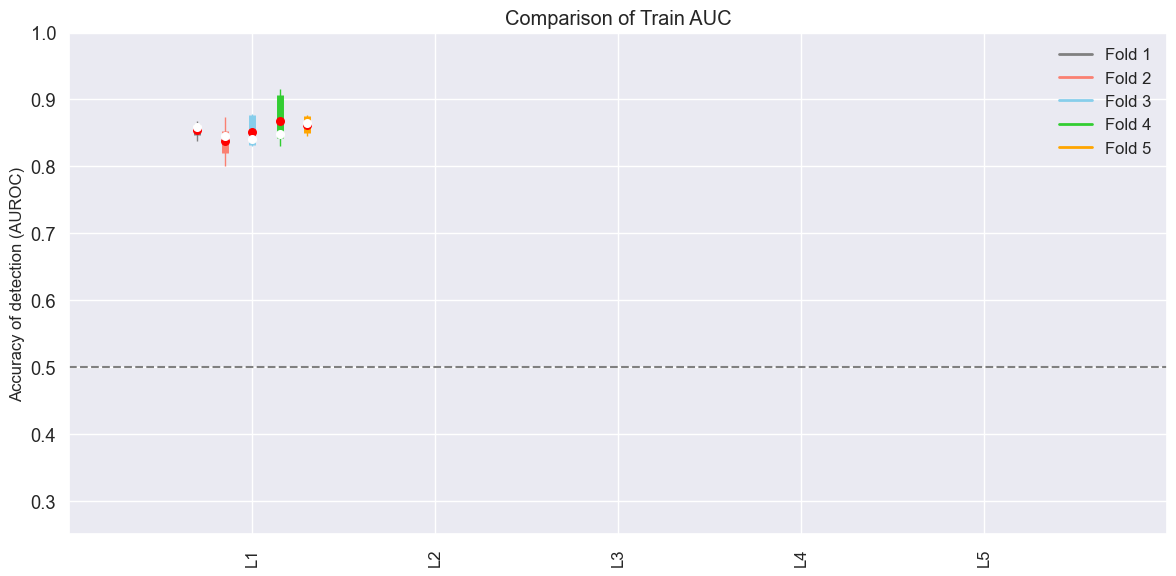

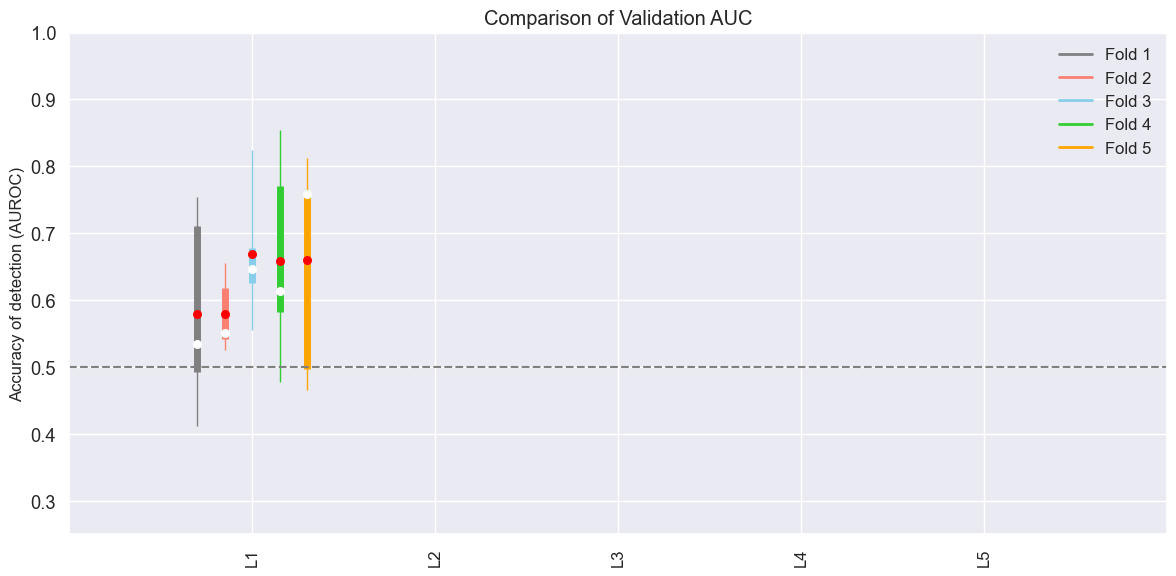

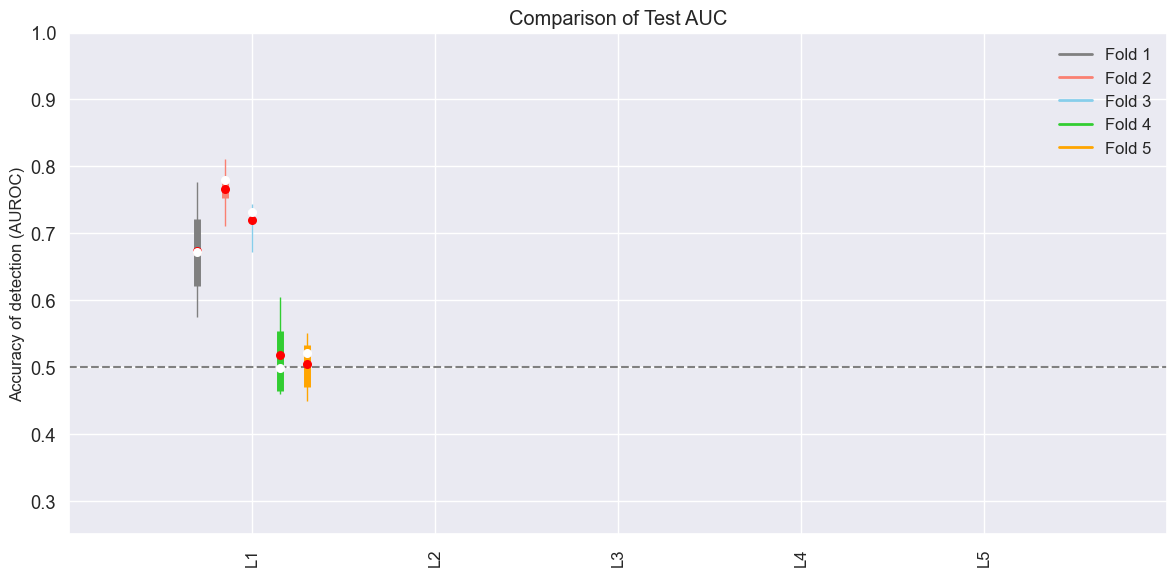

In [634]:
# MAIN SCRIPT

# Assuming hp_star_all_folds, hp_all_folds, train_all_folds, val_all_folds, test_all_folds
# are obtained from the previous code using the load_and_process_folds_separately function

# Labels
labels = [
    "L1", "L2", "L3", "L4", "L5",
    # "Lethality", "Metastasis", "Gleason 1", "Gleason 2", "Relapse"
    # "LOH2", "CHD1", "MAP3K7",
    # "NKX3.1", "MYC", "PTEN", "PTEN (HD)", 
    # "BRCA2", "RB1", "EDNRD",
    # "CDH1", "TP53", "TMPRSS2:ERG"
]

# Prepare data for all folds
train_all_stars = []
val_all_stars = []
test_all_stars = []

for i in range(len(hp_star_all_folds)):
    hp_star = hp_star_all_folds[i]
    hp_keys = collapse_columns_2Darray_to_string(hp_all_folds[i][:,2:5], sep="_")
    
    train_star = prepare_fold_data(hp_star, hp_keys, train_all_folds[i])
    val_star = prepare_fold_data(hp_star, hp_keys, val_all_folds[i])
    test_star = prepare_fold_data(hp_star, hp_keys, test_all_folds[i])
    
    train_all_stars.append(train_star)
    val_all_stars.append(val_star)
    test_all_stars.append(test_star)

# Plot train AUCs
plot_auc_bars(train_all_stars, labels, "Comparison of Train AUC")
# plot_auc_violin(train_all_stars, labels, "Comparison of Train AUC")

# Plot validation AUCs
plot_auc_bars(val_all_stars, labels, "Comparison of Validation AUC")
# plot_auc_violin(val_all_stars, labels, "Comparison of Validation AUC")

# Plot test AUCs
plot_auc_bars(test_all_stars, labels, "Comparison of Test AUC")
# plot_auc_violin(test_all_stars, labels, "Comparison of Test AUC")
